In [1]:
import os
import shutil
import numpy as np
import pandas as pd
import scanpy as sc
from banksy.main import median_dist_to_nearest_neighbour
from banksy.initialize_banksy import initialize_banksy
from banksy.embed_banksy import generate_banksy_matrix
from banksy.main import concatenate_all
from banksy_utils.umap_pca import pca_umap
from banksy.cluster_methods import run_Leiden_partition
from banksy.plot_banksy import plot_results
import matplotlib.pyplot as plt
import warnings
import bpcells.experimental
import scipy.sparse
import time

warnings.filterwarnings("ignore")
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'


D:\PycharmProjects\Banksy_py\banksy\cluster_methods.py:18: UserWarning: 
No rpy2 installed. BANKSY will run, but mclust will not work.
Note: you can still use the default leiden option for clustering.
Install rpy2 and R in your conda environment if you want to use mclust for clustering.

  warnings.warn(warn_str)


In [2]:
def safe_create_bpcells_matrix(matrix, output_dir, overwrite=True):
    """安全创建BPCells矩阵，处理已存在目录的情况"""
    original_dir = output_dir

    # 处理已存在的目录
    if os.path.exists(output_dir):
        if overwrite:
            print(f"删除已存在的目录: {output_dir}")
            try:
                shutil.rmtree(output_dir)
            except Exception as e:
                print(f"删除目录失败: {e}")
                # 如果删除失败，添加时间戳
                timestamp = int(time.time())
                output_dir = f"{original_dir}_{timestamp}"
                print(f"使用新名称: {output_dir}")
        else:
            # 添加时间戳避免冲突
            timestamp = int(time.time())
            output_dir = f"{original_dir}_{timestamp}"
            print(f"目录已存在，使用新名称: {output_dir}")

    # 确保目录不存在
    while os.path.exists(output_dir):
        timestamp = int(time.time())
        output_dir = f"{original_dir}_{timestamp}"
        print(f"目录仍存在，使用名称: {output_dir}")
        time.sleep(1)  # 等待1秒确保时间戳不同

    # 创建BPCells矩阵
    try:
        if scipy.sparse.issparse(matrix):
            bp_matrix = bpcells.experimental.DirMatrix.from_scipy_sparse(
                matrix.tocsc(),
                output_dir
            )
        else:
            bp_matrix = bpcells.experimental.DirMatrix.from_scipy_sparse(
                scipy.sparse.csc_matrix(matrix),
                output_dir
            )

        print(f"✓ BPCells矩阵创建成功: {output_dir}")
        return bp_matrix, output_dir

    except Exception as e:
        print(f"✗ BPCells矩阵创建失败: {e}")
        raise


# 清理旧的BPCells目录
def cleanup_old_bpcells_dirs():
    """清理旧的BPCells目录"""
    dirs_to_clean = [
        "bpcells_counts_matrix",
        "bpcells_hvg_matrix"
    ]

    for dir_name in dirs_to_clean:
        if os.path.exists(dir_name):
            try:
                shutil.rmtree(dir_name)
                print(f"✓ 清理旧目录: {dir_name}")
            except Exception as e:
                print(f"✗ 清理目录失败 {dir_name}: {e}")
                # 重命名为备份
                backup_name = f"{dir_name}_backup_{int(time.time())}"
                try:
                    os.rename(dir_name, backup_name)
                    print(f"→ 重命名为备份: {backup_name}")
                except:
                    pass


# 开始分析前清理
print("=" * 60)
print("🧹 清理旧的BPCells文件...")
cleanup_old_bpcells_dirs()

# 读取数据
print("📖 读取数据...")
adata = sc.read_h5ad('./data/visium_hd_processed/visium_hd_adata.h5ad')
adata.var_names_make_unique()
adata.obs['sample'] = 'P1_CRC'
print(f"原始数据: {adata.n_obs} 细胞, {adata.n_vars} 基因")

🧹 清理旧的BPCells文件...
✓ 清理旧目录: bpcells_counts_matrix
✓ 清理旧目录: bpcells_hvg_matrix
📖 读取数据...
原始数据: 393543 细胞, 19059 基因


🔍 质量控制...


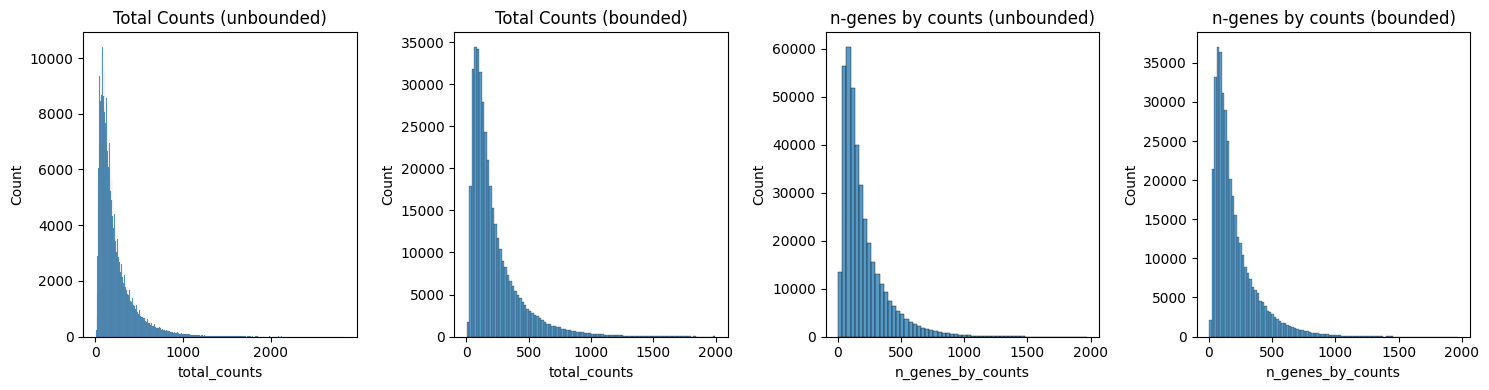

In [3]:
from banksy_utils.plot_utils import plot_qc_hist, plot_cell_positions
# 质控和过滤 (保持原有逻辑)
print("🔍 质量控制...")
adata.var_names_make_unique()
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    adata, 
    qc_vars=['mt'], 
    percent_top=None, 
    log1p=False, 
    inplace=True
)
hist_bin_options = ['auto', 100, 60, 100]

plot_qc_hist(adata,
        total_counts_cutoff=2000,
        n_genes_high_cutoff=2000, 
        n_genes_low_cutoff= 0,
        bin_options = hist_bin_options)

In [4]:
from banksy_utils.filter_utils import filter_cells
adata = filter_cells(adata, 
             min_count=150,   # 设定为150，更好地排除低质量细胞
             max_count=1000,  # 设为1500，覆盖大多数高质量细胞但排除异常值
             MT_filter=15,    # 维持15%的线粒体基因过滤阈值
             gene_filter=150) # 降低至150，保留更多有效细胞

Cells before filtering: 393543
Cells after count filter: 200623

cells after MT filter: 200623
Genes after minimum cells per gene filter: 12440


In [5]:
from banksy_utils.load_data import load_adata, display_adata
display_adata(adata)

Displaying adata Object and their attributes
Adata attributes and dimensions:


AnnData object with n_obs × n_vars = 200623 × 12440
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial'

Matrix sparsity: 59287488 filled elements (0.02) out of 2495750120
max: 231.0, min: 1.0

Displaying observations (adata.obs)


,in_tissue,array_row,array_col,sample,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,n_counts
s_008um_00515_00112-1,1,515,112,P1_CRC,399,436.0,0.0,0.0,436.0
s_008um_00383_00696-1,1,383,696,P1_CRC,257,287.0,0.0,0.0,287.0
s_008um_00526_00291-1,1,526,291,P1_CRC,182,194.0,0.0,0.0,194.0
s_008um_00078_00444-1,1,78,444,P1_CRC,215,242.0,0.0,0.0,242.0
s_008um_00123_00164-1,1,123,164,P1_CRC,318,341.0,0.0,0.0,341.0
...,...,...,...,...,...,...,...,...,...
s_008um_00631_00323-1,1,631,323,P1_CRC,261,277.0,0.0,0.0,277.0
s_008um_00653_00166-1,1,653,166,P1_CRC,169,179.0,0.0,0.0,179.0
s_008um_00353_00477-1,1,353,477,P1_CRC,188,198.0,0.0,0.0,198.0
s_008um_00373_00222-1,1,373,222,P1_CRC,242,259.0,0.0,0.0,259.0


Displaying variables (adata.var)


,gene_ids,feature_types,genome,mt,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,n_cells
Xkr4,ENSMUSG00000051951,Gene Expression,mm10,False,5089,0.013351,98.706876,5254.0,4054
Sox17,ENSMUSG00000025902,Gene Expression,mm10,False,745,0.001972,99.810694,776.0,482
Lypla1,ENSMUSG00000025903,Gene Expression,mm10,False,2108,0.005425,99.464353,2135.0,1616
Tcea1,ENSMUSG00000033813,Gene Expression,mm10,False,12070,0.031943,96.932991,12571.0,9174
Rgs20,ENSMUSG00000002459,Gene Expression,mm10,False,4798,0.012466,98.780819,4906.0,3477
...,...,...,...,...,...,...,...,...,...
mt-Nd4,ENSMUSG00000064363,Gene Expression,mm10,False,130537,0.439360,66.830308,172907.0,79769
mt-Nd5,ENSMUSG00000064367,Gene Expression,mm10,False,137032,0.474904,65.179917,186895.0,85748
mt-Nd6,ENSMUSG00000064368,Gene Expression,mm10,False,22495,0.060016,94.283979,23619.0,13366
mt-Cytb,ENSMUSG00000064370,Gene Expression,mm10,False,221308,0.964616,43.765230,379618.0,132423


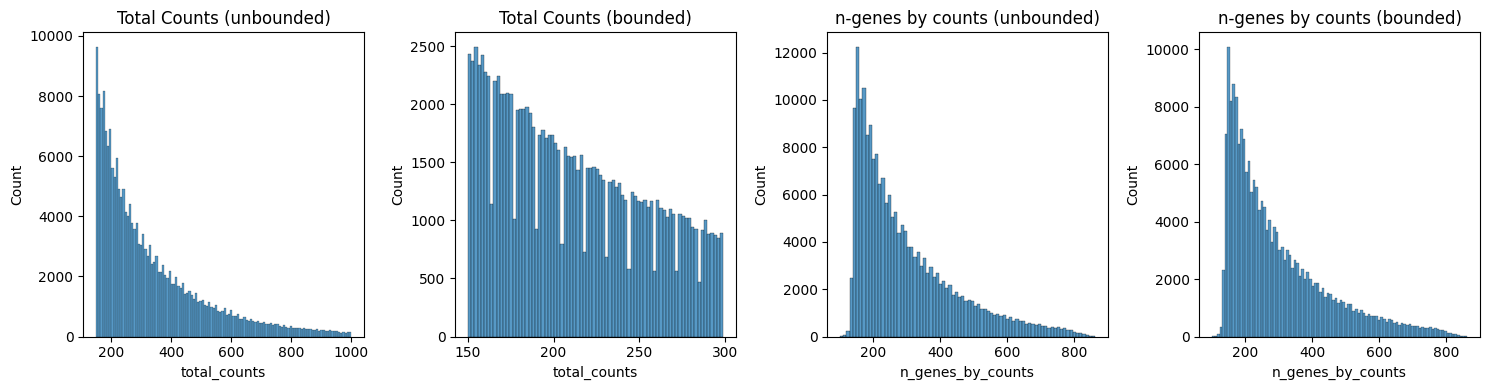

In [6]:
# 设置直方图的分箱选项
# 'auto'用于第一个图形，80个箱用于第二和第三个图形，100个箱用于第四个图形
hist_bin_options = ['auto', 80, 80, 100]

plot_qc_hist(adata, 
         total_counts_cutoff = 300, # 用于可视化的总计数截止值
         n_genes_high_cutoff = 1000, # 用于可视化的基因数量上限截止值
         n_genes_low_cutoff = 0, # 用于可视化的基因数量下限截止值
         bin_options = hist_bin_options)

In [7]:
# === BPCells优化开始 ===
print("\n" + "=" * 60)
print("🚀 BPCells优化处理")
print("=" * 60)

# 1. 将原始计数矩阵转换为BPCells格式以提高存储效率
print("💾 转换原始计数矩阵到BPCells格式...")
adata.layers["counts"] = adata.X.copy()

# 创建BPCells矩阵存储原始数据
try:
    bp_counts, counts_dir = safe_create_bpcells_matrix(
        adata.X,
        "bpcells_counts_matrix",
        overwrite=True
    )

    # 设置多线程处理以提高性能
    bp_counts.threads = 4
    print(f"✓ BPCells原始矩阵: {bp_counts.shape}")
    print(f"  存储位置: {counts_dir}")

except Exception as e:
    print(f"✗ BPCells原始矩阵创建失败: {e}")
    print("→ 继续使用标准流程...")
    bp_counts = None
    counts_dir = None


🚀 BPCells优化处理
💾 转换原始计数矩阵到BPCells格式...
✓ BPCells矩阵创建成功: bpcells_counts_matrix
✓ BPCells原始矩阵: (200623, 12440)
  存储位置: bpcells_counts_matrix


In [8]:
print("\n⚖️ 数据标准化...")


def normalize_with_bpcells_fixed(bp_matrix, batch_size=1000, target_sum=10000):
    """使用BPCells进行内存高效的标准化"""
    if bp_matrix is None:
        print("BPCells矩阵不可用，跳过BPCells标准化")
        return None

    try:
        n_cells = bp_matrix.shape[1]
        cell_sums = np.zeros(n_cells)

        print(f"  计算 {n_cells} 个细胞的标准化因子...")

        # 批量处理来避免单个索引的问题
        for i in range(0, n_cells, batch_size):
            end_idx = min(i + batch_size, n_cells)
            batch_cols = list(range(i, end_idx))

            try:
                batch_matrix = bp_matrix[:, batch_cols]
                batch_sums = np.array(batch_matrix.sum(axis=0)).flatten()
                cell_sums[i:end_idx] = batch_sums

                if (i // batch_size + 1) % 5 == 0:
                    print(f"    已处理 {end_idx}/{n_cells} 个细胞 ({end_idx / n_cells * 100:.1f}%)")

            except Exception as e:
                print(f"    批次 {i}-{end_idx} 处理失败: {e}")
                # 使用默认值
                cell_sums[i:end_idx] = 1000

        # 避免除零错误
        cell_sums[cell_sums == 0] = 1

        # 计算标准化因子
        size_factors = target_sum / cell_sums
        print(f"  ✓ 标准化因子范围: {size_factors.min():.3f} - {size_factors.max():.3f}")
        return size_factors

    except Exception as e:
        print(f"  ✗ BPCells标准化失败: {e}")
        return None


# 计算标准化因子（如果BPCells可用）
if bp_counts is not None:
    size_factors = normalize_with_bpcells_fixed(bp_counts, batch_size=500)
else:
    size_factors = None

# 应用标准化 (使用scanpy)
sc.pp.normalize_total(adata, target_sum=10000)
sc.pp.log1p(adata)
print("✓ 数据标准化完成")


⚖️ 数据标准化...
  计算 12440 个细胞的标准化因子...
    已处理 2500/12440 个细胞 (20.1%)
    已处理 5000/12440 个细胞 (40.2%)
    已处理 7500/12440 个细胞 (60.3%)
    已处理 10000/12440 个细胞 (80.4%)
    已处理 12440/12440 个细胞 (100.0%)
  ✓ 标准化因子范围: 0.024 - 66.225
✓ 数据标准化完成


In [9]:
# 3. 高变基因选择
print("\n🧬 选择高变基因...")
sc.pp.highly_variable_genes(
    adata,
    flavor='seurat',
    n_top_genes=2000
)

n_hvg = sum(adata.var.highly_variable)
print(f"✓ 选择了 {n_hvg} 个高变基因")

# 保存原始数据
adata.raw = adata
adata = adata[:, adata.var.highly_variable]


🧬 选择高变基因...
✓ 选择了 2000 个高变基因


In [10]:
# 将高变基因矩阵转换为BPCells格式
print("💾 转换高变基因矩阵到BPCells格式...")
try:
    bp_hvg, hvg_dir = safe_create_bpcells_matrix(
        adata.X,
        "bpcells_hvg_matrix",
        overwrite=True
    )

    bp_hvg.threads = 4
    print(f"✓ BPCells高变基因矩阵: {bp_hvg.shape}")
    print(f"  存储位置: {hvg_dir}")

except Exception as e:
    print(f"✗ BPCells高变基因矩阵创建失败: {e}")
    print("→ 继续使用标准流程...")
    bp_hvg = None
    hvg_dir = None

💾 转换高变基因矩阵到BPCells格式...
✓ BPCells矩阵创建成功: bpcells_hvg_matrix
✓ BPCells高变基因矩阵: (200623, 2000)
  存储位置: bpcells_hvg_matrix


In [11]:
# 4. 验证BPCells矩阵
print("\n🔍 验证BPCells矩阵...")


def validate_bpcells_matrix(bp_matrix, original_matrix, n_samples=30):
    """验证BPCells矩阵与原始矩阵的一致性"""
    if bp_matrix is None:
        print("  BPCells矩阵不可用，跳过验证")
        return False

    try:
        n_cells = min(n_samples, bp_matrix.shape[1])
        n_genes = min(50, bp_matrix.shape[0])

        # 随机选择
        sample_cols = np.random.choice(bp_matrix.shape[1], n_cells, replace=False)
        sample_rows = np.random.choice(bp_matrix.shape[0], n_genes, replace=False)

        # 比较子矩阵
        bp_sample = bp_matrix[list(sample_rows)][:, list(sample_cols)].toarray()

        if scipy.sparse.issparse(original_matrix):
            orig_sample = original_matrix[sample_rows][:, sample_cols].toarray()
        else:
            orig_sample = original_matrix[sample_rows][:, sample_cols]

        # 计算相关系数
        bp_flat = bp_sample.flatten()
        orig_flat = orig_sample.flatten()

        if np.sum(bp_flat) == 0 or np.sum(orig_flat) == 0:
            print("  ⚠ 检测到全零矩阵，跳过验证")
            return True

        correlation = np.corrcoef(bp_flat, orig_flat)[0, 1]
        print(f"  相关系数: {correlation:.6f}")

        is_valid = correlation > 0.99
        print(f"  {'✓ 验证通过' if is_valid else '⚠ 验证失败'}")
        return is_valid

    except Exception as e:
        print(f"  ✗ 验证过程出错: {e}")
        return False
    
    # 验证矩阵
is_valid = validate_bpcells_matrix(bp_hvg, adata.X)



🔍 验证BPCells矩阵...
  相关系数: 0.996684
  ✓ 验证通过



🎯 BANKSY空间分析
🔗 构建空间邻接图...

Median distance to closest cell = 29.19530221316463

---- Ran median_dist_to_nearest_neighbour in 2.46 s ----

⚖️ 计算空间权重...

Median distance to closest cell = 29.19530221316463

---- Ran median_dist_to_nearest_neighbour in 2.34 s ----
---- Ran generate_spatial_distance_graph in 3.94 s ----
---- Ran row_normalize in 0.77 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 9.43 s ----

----- Plotting Edge Histograms for m = 0 -----

Edge weights (distances between cells): median = 58.38837780299416, mode = 62.765963141353545

---- Ran plot_edge_histogram in 0.13 s ----

Edge weights (weights between cells): median = 0.057102909317393584, mode = 0.02791093518019961

---- Ran plot_edge_histogram in 0.10 s ----
---- Ran generate_spatial_distance_graph in 5.87 s ----
---- Ran theta_from_spatial_graph in 3.71 s ----
---- Ran row_normalize in 0.72 s ----
---- Ran generate_spatial_weights_fixed_nbrs in 15.14 s ----

----- Plotting Edge Histograms for m = 1 -----


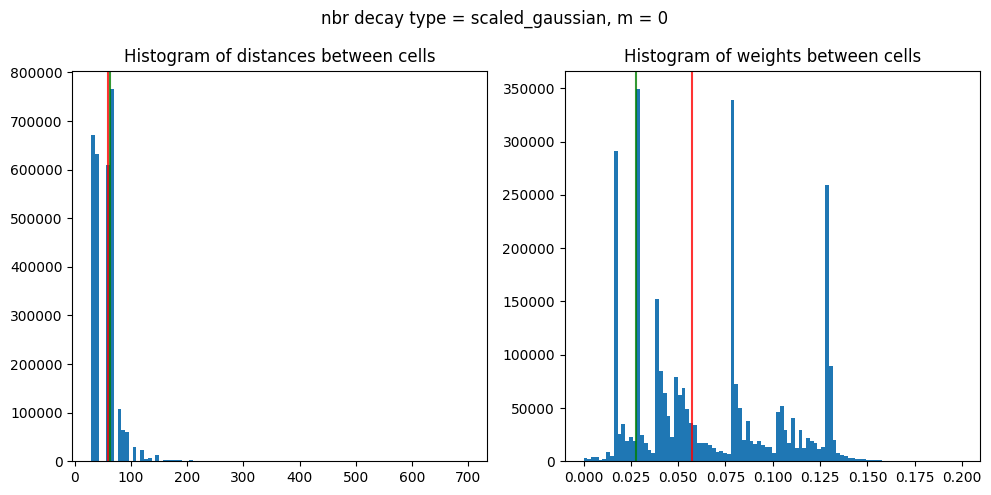

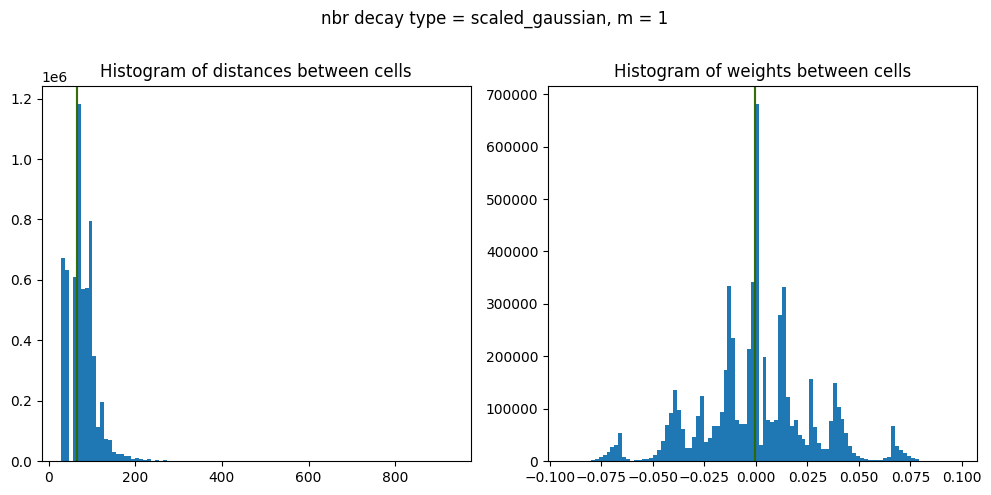

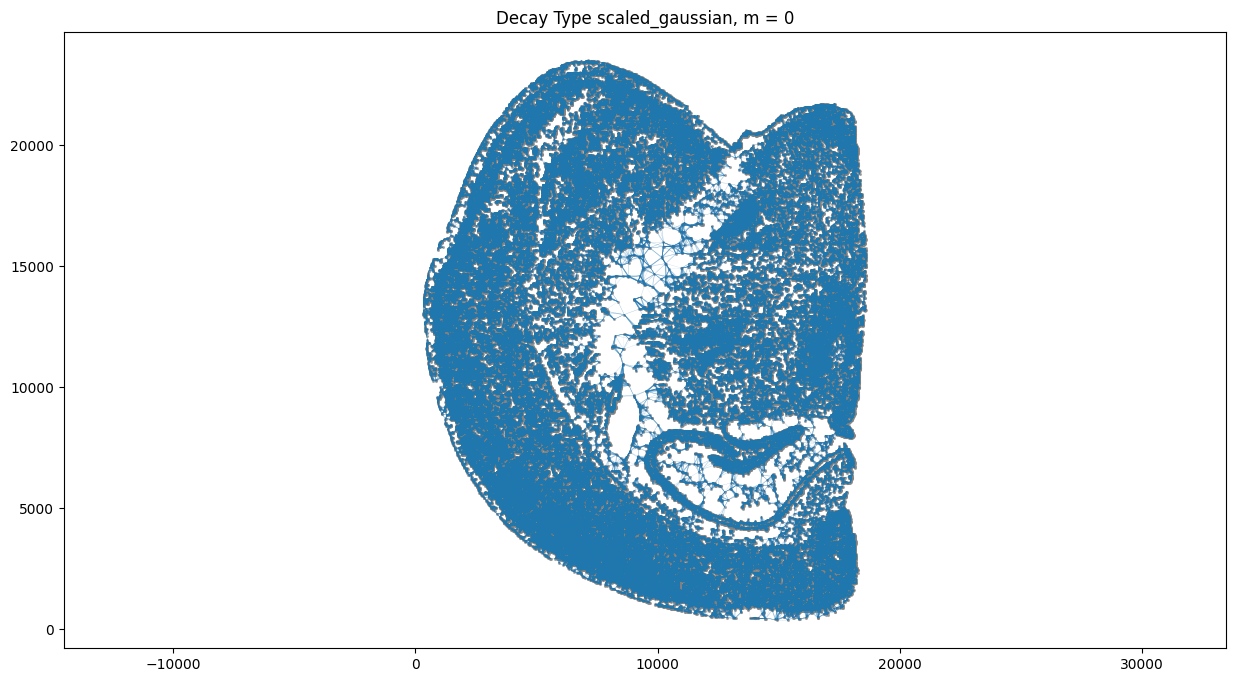

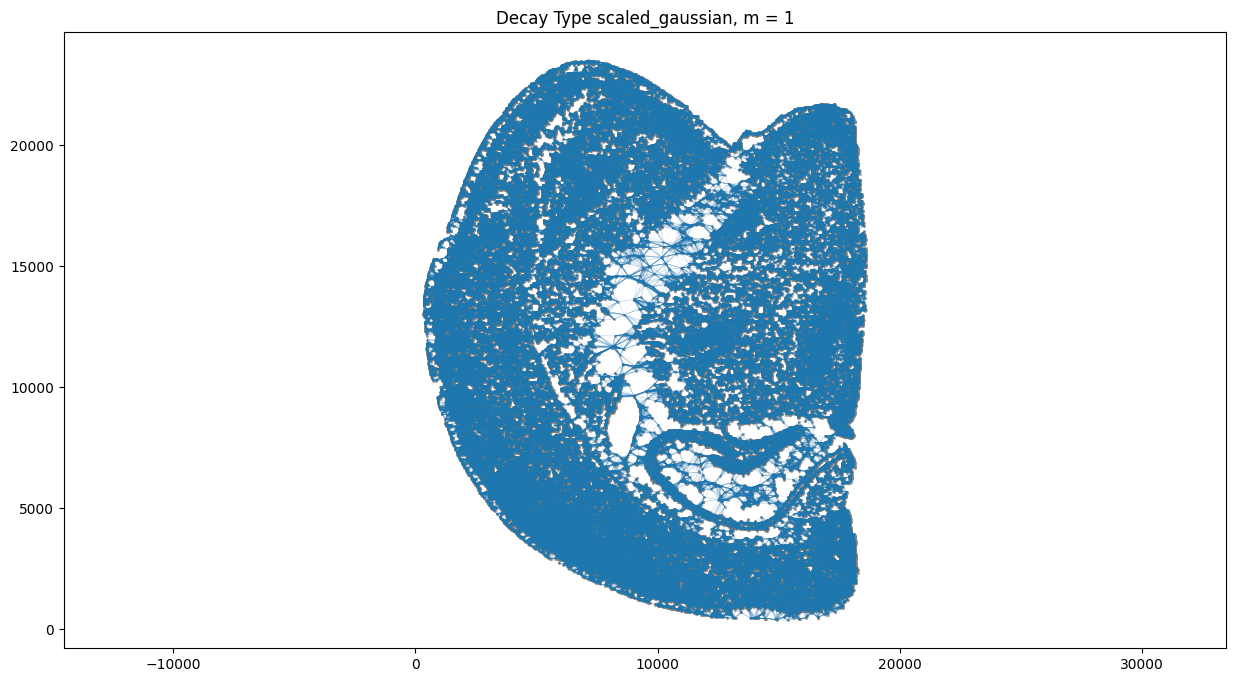

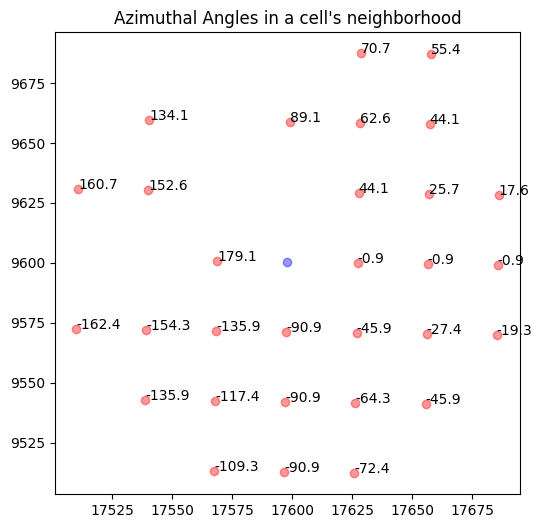

In [12]:
# === BANKSY分析部分 ===
print("\n" + "=" * 60)
print("🎯 BANKSY空间分析")
print("=" * 60)

# 构建空间最近邻图
print("🔗 构建空间邻接图...")
nbrs = median_dist_to_nearest_neighbour(adata, key="spatial")

# 生成空间权重
print("⚖️ 计算空间权重...")
k_geom = 15
max_m = 1
nbr_weight_decay = "scaled_gaussian"
coord_keys = ('xcoord', 'ycoord', 'spatial')

banksy_dict = initialize_banksy(
    adata,
    coord_keys,
    k_geom,
    nbr_weight_decay=nbr_weight_decay,
    max_m=max_m,
    plt_edge_hist=True,
    plt_nbr_weights=True,
    plt_agf_angles=False,
    plt_theta=True,
)

In [13]:
# 生成BANKSY矩阵
print("🧮 生成BANKSY嵌入...")
resolutions = [0.5]
pca_dims = [20]
lambda_list = [0.2]

banksy_dict, banksy_matrix = generate_banksy_matrix(
    adata,
    banksy_dict,
    lambda_list,
    max_m
)

🧮 生成BANKSY嵌入...
Runtime Jun-19-2025-19-43

2000 genes to be analysed:
Gene List:
Index(['Sox17', 'Rgs20', 'Adhfe1', 'Prex2', 'Eya1', 'Paqr8', 'Efhc1', 'Ptpn18',
       'Arid5a', 'Coa5',
       ...
       'Sat1', 'Car5b', 'Gpm6b', 'Tlr7', 'mt-Nd2', 'mt-Co2', 'mt-Atp8',
       'mt-Nd3', 'mt-Nd6', 'mt-Cytb'],
      dtype='object', length=2000)
Check if X contains only finite (non-NAN) values
Decay Type: scaled_gaussian
Weights Object: {'weights': {0: <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3009345 stored elements and shape (200623, 200623)>, 1: <Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 6018690 stored elements and shape (200623, 200623)>}}

Nbr matrix | Mean: 0.05999999865889549 | Std: 0.23000000417232513
Size of Nbr | Shape: (200623, 2000)
Top 3 entries of Nbr Mat:

[[0.         0.         0.        ]
 [0.         0.11358554 0.        ]
 [0.         0.         0.        ]]

AGF matrix | Mean: 0.029999999329447746 | Std: 0.07999999821186066
Size

In [14]:
# 非空间结果对比
banksy_dict["nonspatial"] = {
    0.0: {"adata": concatenate_all([adata.X], 0, adata=adata), }
}

# === BPCells数据统计 ===
print("\n📊 BPCells数据统计分析...")


def efficient_data_processing_with_bpcells(bp_matrix, batch_size=1000):
    """使用BPCells进行高效的数据预处理"""
    if bp_matrix is None:
        print("  BPCells矩阵不可用，跳过统计分析")
        return np.array([]), np.array([])

    try:
        n_cells = bp_matrix.shape[1]
        n_genes = bp_matrix.shape[0]

        print(f"  分析 {n_genes} 个基因, {n_cells} 个细胞")

        gene_means = np.zeros(n_genes)
        cell_counts = np.zeros(n_cells)
        total_umi = 0

        for i in range(0, n_cells, batch_size):
            end_idx = min(i + batch_size, n_cells)
            batch_cols = list(range(i, end_idx))
            batch_matrix = bp_matrix[:, batch_cols].toarray()

            gene_means += batch_matrix.sum(axis=1)
            cell_counts[i:end_idx] = batch_matrix.sum(axis=0)
            total_umi += batch_matrix.sum()

            if (i // batch_size + 1) % 3 == 0:
                print(f"    处理进度: {end_idx}/{n_cells} ({end_idx / n_cells * 100:.1f}%)")

        gene_means /= n_cells

        print(f"  ✓ 统计完成:")
        print(f"    基因表达均值: {gene_means.min():.3f} - {gene_means.max():.3f}")
        print(f"    细胞UMI计数: {cell_counts.min():.0f} - {cell_counts.max():.0f}")
        print(f"    总UMI数: {total_umi:,.0f}")

        return gene_means, cell_counts

    except Exception as e:
        print(f"  ✗ 统计分析失败: {e}")
        return np.array([]), np.array([])


# 使用BPCells进行数据统计
gene_stats, cell_stats = efficient_data_processing_with_bpcells(bp_hvg, batch_size=500)

Scale factors squared: [1.]
Scale factors: [1.]

📊 BPCells数据统计分析...
  分析 200623 个基因, 2000 个细胞
    处理进度: 1500/2000 (75.0%)
  ✓ 统计完成:
    基因表达均值: 0.006 - 0.222
    细胞UMI计数: 429 - 624926
    总UMI数: 20,123,016


In [15]:
# PCA和UMAP
print("\n🔄 PCA和UMAP降维...")
pca_umap(
    banksy_dict,
    pca_dims=pca_dims,
    add_umap=True,
    plt_remaining_var=False,
)


🔄 PCA和UMAP降维...
Current decay types: ['scaled_gaussian', 'nonspatial']

Reducing dims of dataset in (Index = scaled_gaussian, lambda = 0.2)
Setting the total number of PC = 20
Original shape of matrix: (200623, 6000)
Reduced shape of matrix: (200623, 20)
------------------------------------------------------------
min_value = -41.18465805053711, mean = 4.532884645414015e-07, max = 64.9470443725586

Conducting UMAP and adding embeddings to adata.obsm["reduced_pc_20_umap"]
UMAP embedding
------------------------------------------------------------
shape: (200623, 2)


AxisArrays with keys: reduced_pc_20, reduced_pc_20_umap

Reducing dims of dataset in (Index = nonspatial, lambda = 0.0)

Setting the total number of PC = 20
Original shape of matrix: (200623, 2000)
Reduced shape of matrix: (200623, 20)
------------------------------------------------------------
min_value = -40.994712829589844, mean = 8.050142241700087e-07, max = 70.21501922607422

Conducting UMAP and adding embeddings to 

In [16]:
# 聚类分析
print("🎭 Leiden聚类...")
results_df, max_num_labels = run_Leiden_partition(
    banksy_dict,
    resolutions,
    num_nn=50,
    num_iterations=-1,
    partition_seed=12345,
    match_labels=True,
)

print(f"✓ 识别出 {max_num_labels} 个聚类")

# 结果可视化
print("🎨 生成可视化结果...")
c_map = 'tab20'
weights_graph = banksy_dict['scaled_gaussian']['weights'][0]


🎭 Leiden聚类...
Decay type: scaled_gaussian
Neighbourhood Contribution (Lambda Parameter): 0.2
reduced_pc_20 

reduced_pc_20_umap 

PCA dims to analyse: [20]

Setting up partitioner for (nbr decay = scaled_gaussian), Neighbourhood contribution = 0.2, PCA dimensions = 20)

Nearest-neighbour weighted graph (dtype: float64, shape: (200623, 200623)) has 10031150 nonzero entries.
---- Ran find_nn in 2637.83 s ----

Nearest-neighbour connectivity graph (dtype: int16, shape: (200623, 200623)) has 10031150 nonzero entries.

(after computing shared NN)
Allowing nearest neighbours only reduced the number of shared NN from 298661985 to 9972538.

Shared nearest-neighbour (connections only) graph (dtype: int16, shape: (200623, 200623)) has 8419161 nonzero entries.

Shared nearest-neighbour (number of shared neighbours as weights) graph (dtype: int16, shape: (200623, 200623)) has 8419161 nonzero entries.

sNN graph data:
[16 10  8 ...  7  5  5]

---- Ran shared_nn in 18.84 s ----


-- Multiplying sNN 

,decay,lambda_param,num_pcs,resolution,num_labels,labels,adata,relabeled
nonspatial_pc20_nc0.00_r0.50,nonspatial,0.0,20,0.5,15,"Label object:\nNumber of labels: 15, number of...",[[[View of AnnData object with n_obs × n_vars ...,"Label object:\nNumber of labels: 15, number of..."
scaled_gaussian_pc20_nc0.20_r0.50,scaled_gaussian,0.2,20,0.5,18,"Label object:\nNumber of labels: 18, number of...",[[[View of AnnData object with n_obs × n_vars ...,"Label object:\nNumber of labels: 18, number of..."


✓ 识别出 18 个聚类
🎨 生成可视化结果...


Saving figure at bpcells_banksy_results\slideseq_mousecerebellum_nonspatial_pc20_nc0.00_r0.50_spatialmap.png
number of labels: 15
---- Ran plot_2d_embeddings in 0.02 s ----

number of labels: 15
---- Ran plot_2d_embeddings in 0.04 s ----

number of labels: 15
---- Ran plot_2d_embeddings in 0.03 s ----

---- Ran row_normalize in 0.00 s ----


matrix multiplying labels x weights x labels-transpose ((15, 200623) x (200623, 200623) x (200623, 15))
Saving figure at bpcells_banksy_results\slideseq_mousecerebellum_scaled_gaussian_pc20_nc0.20_r0.50_spatialmap.png
number of labels: 18
---- Ran plot_2d_embeddings in 0.04 s ----

number of labels: 18
---- Ran plot_2d_embeddings in 0.04 s ----

number of labels: 18
---- Ran plot_2d_embeddings in 0.03 s ----

---- Ran row_normalize in 0.00 s ----


matrix multiplying labels x weights x labels-transpose ((18, 200623) x (200623, 200623) x (200623, 18))


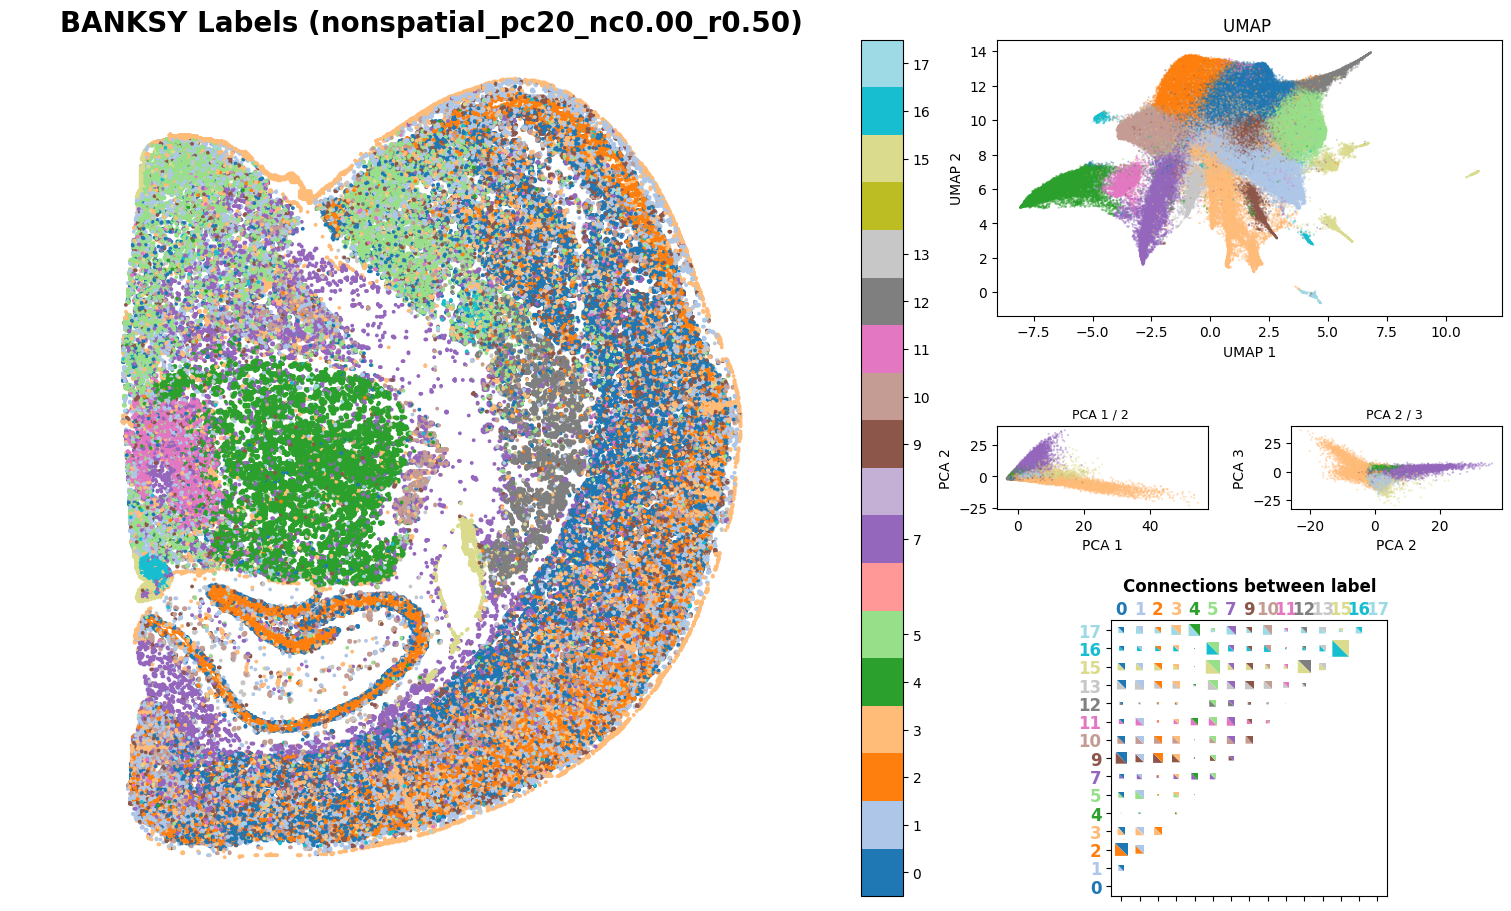

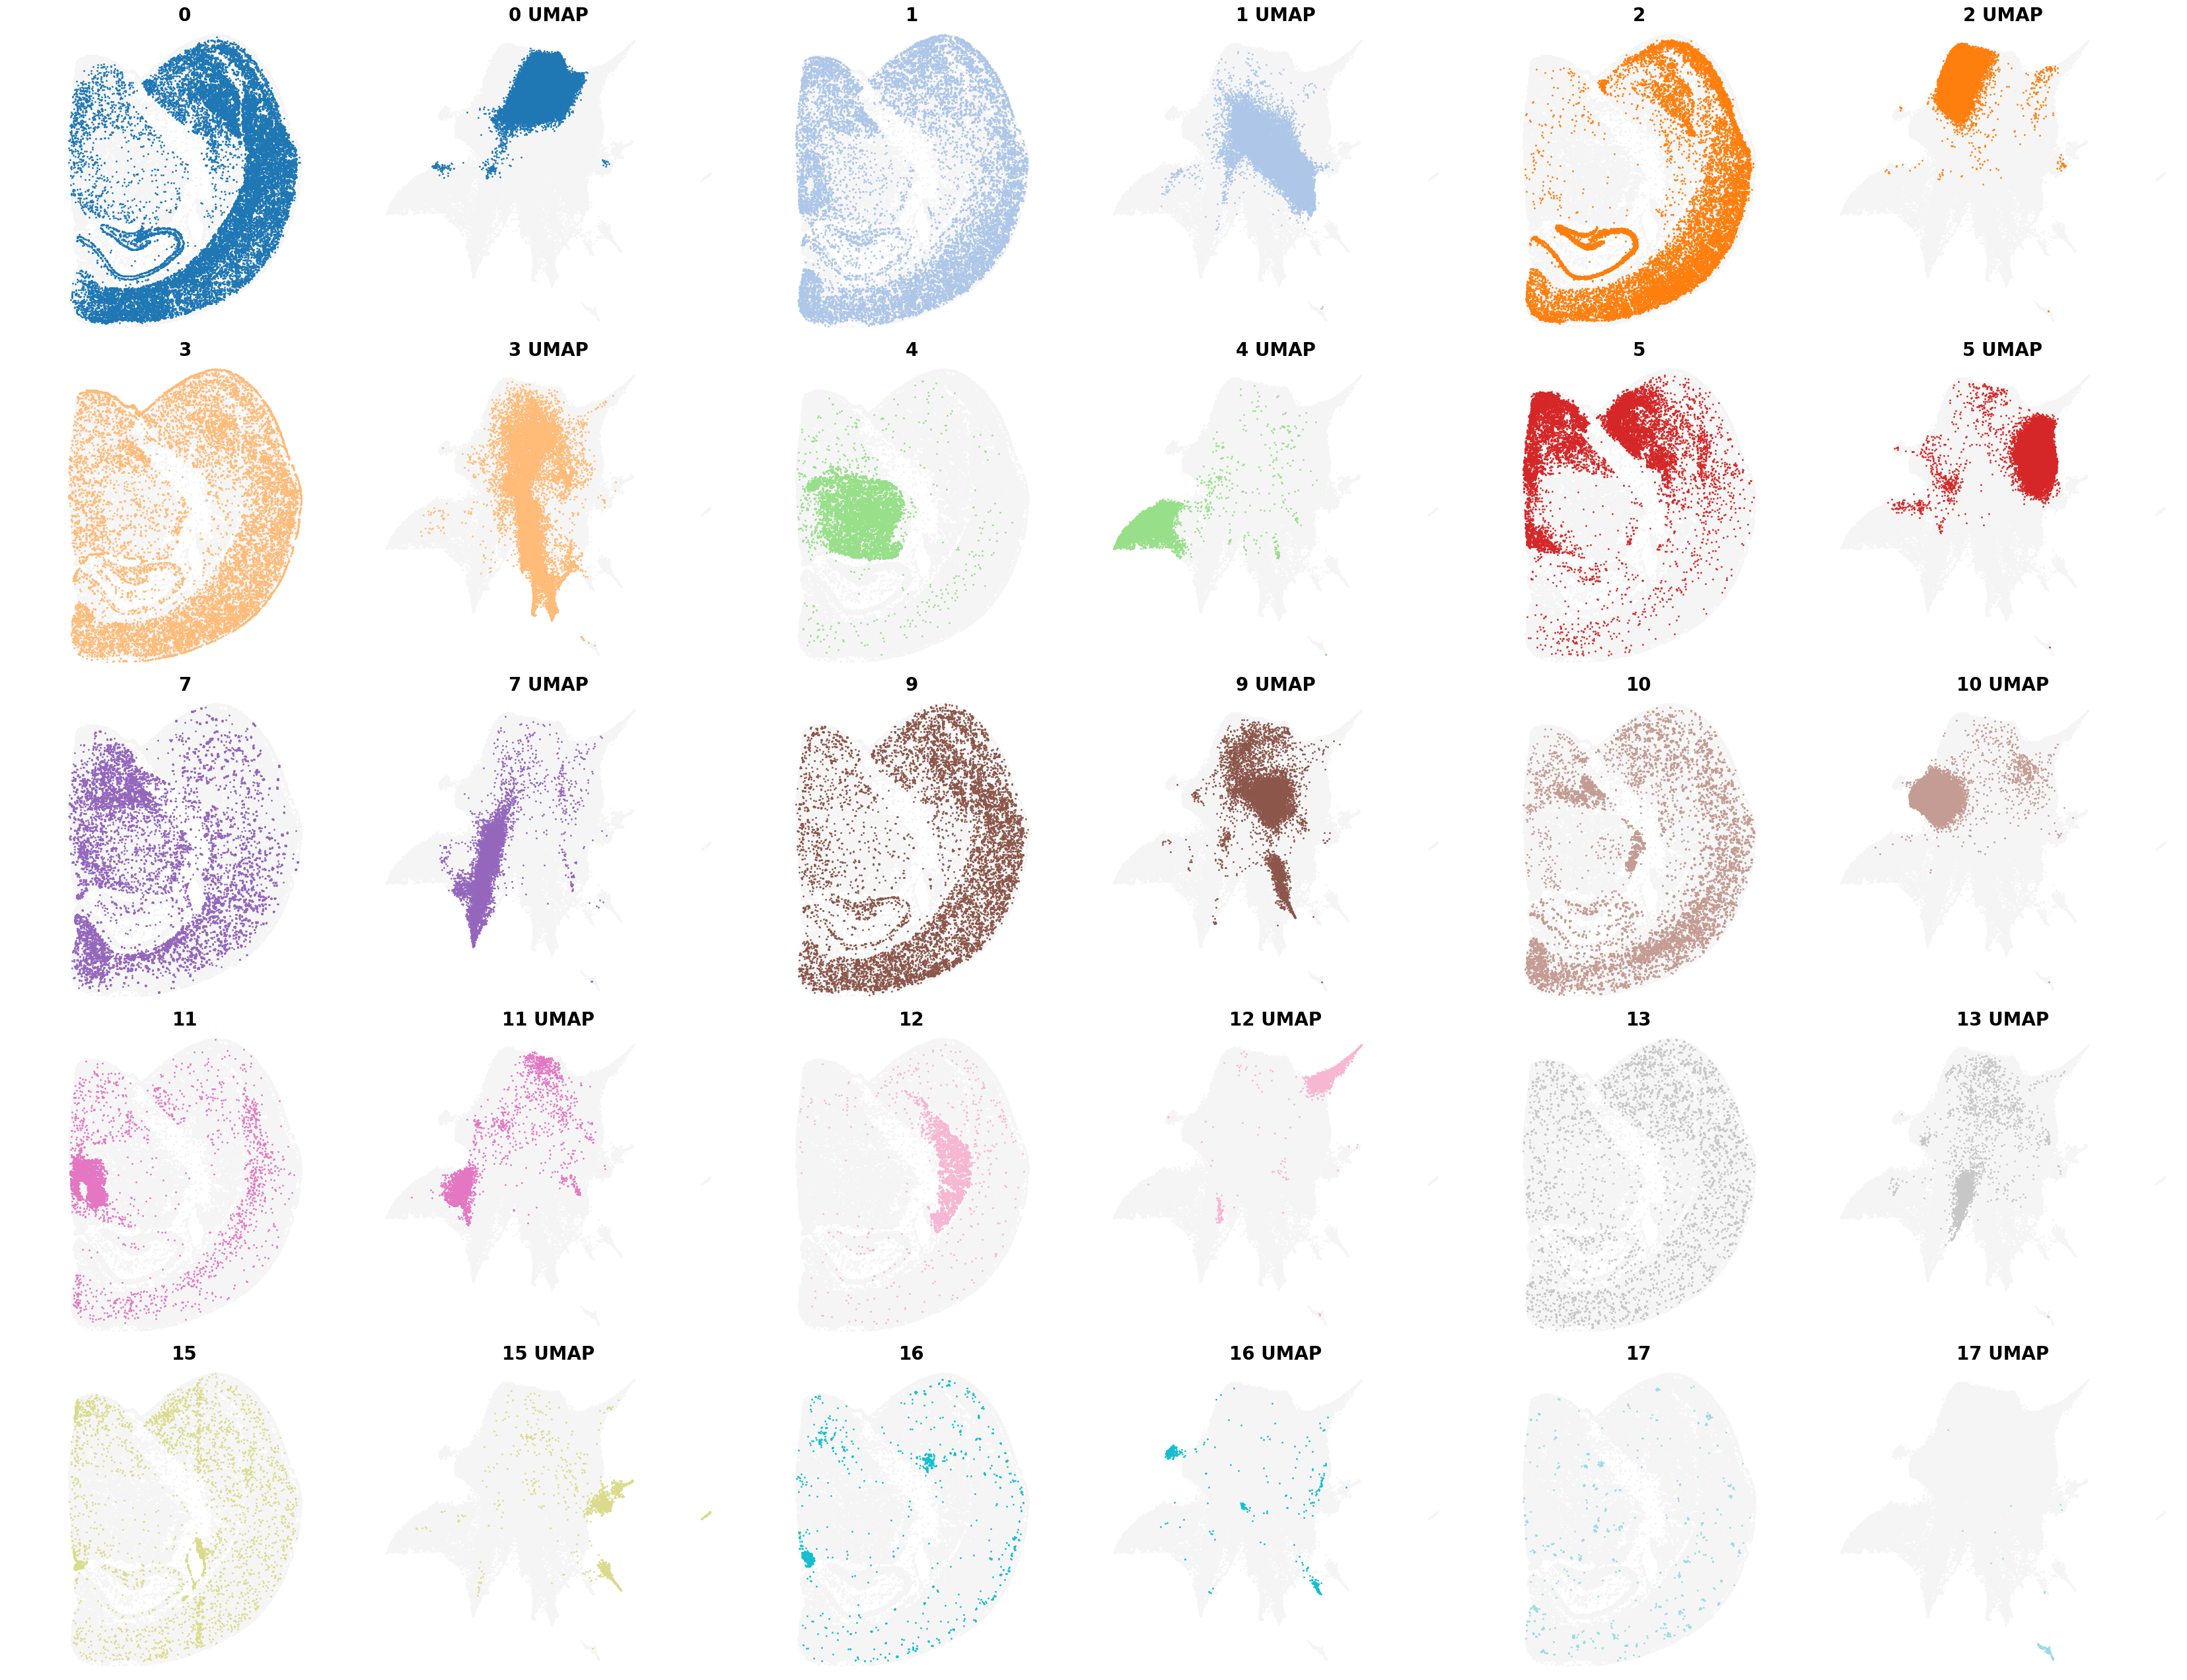

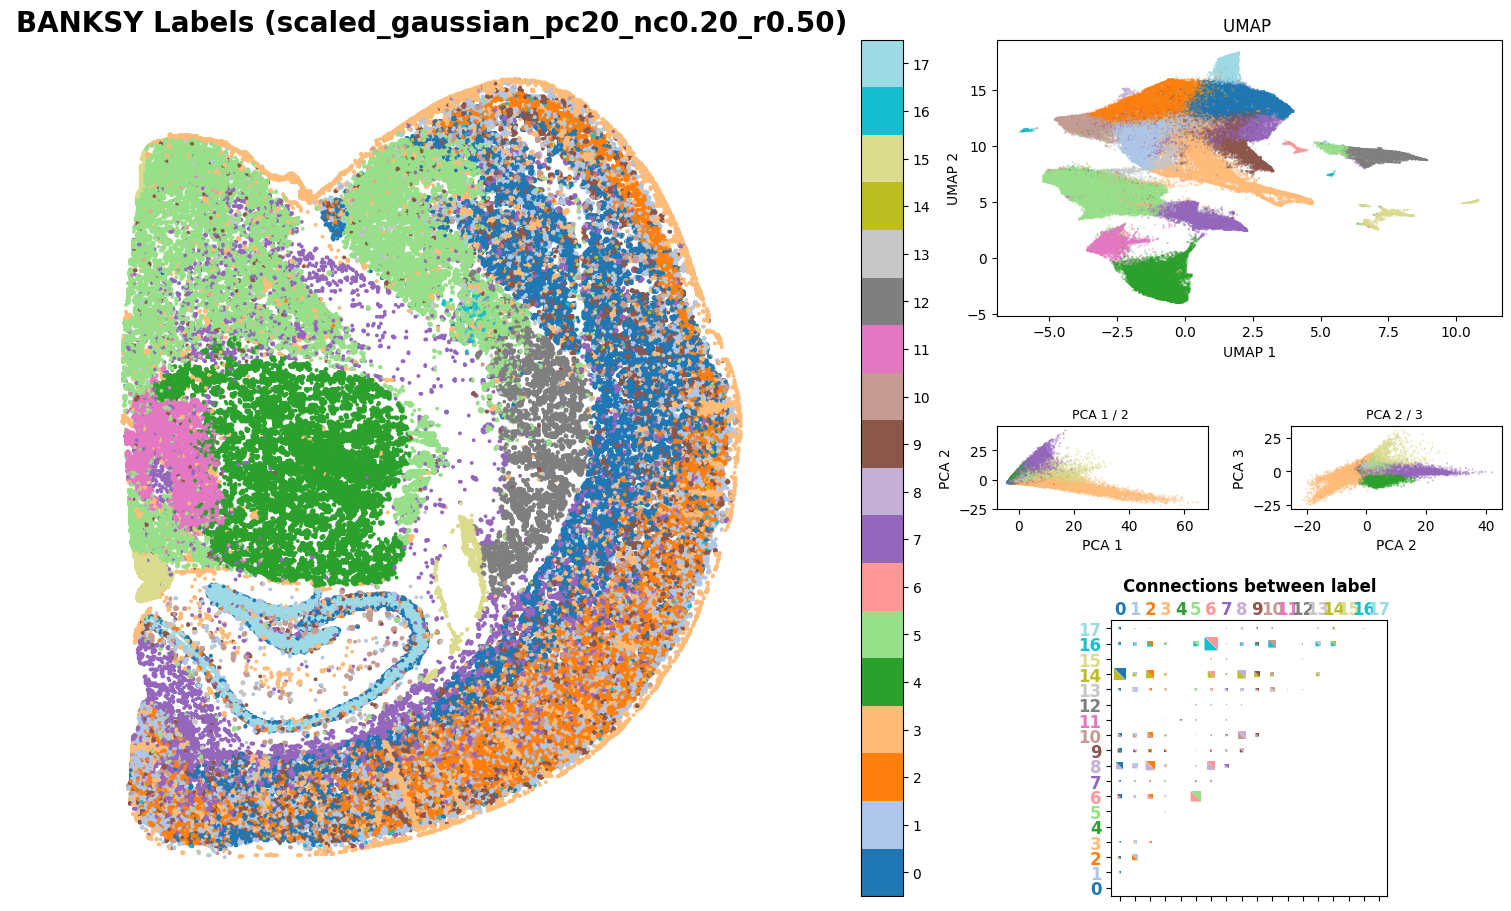

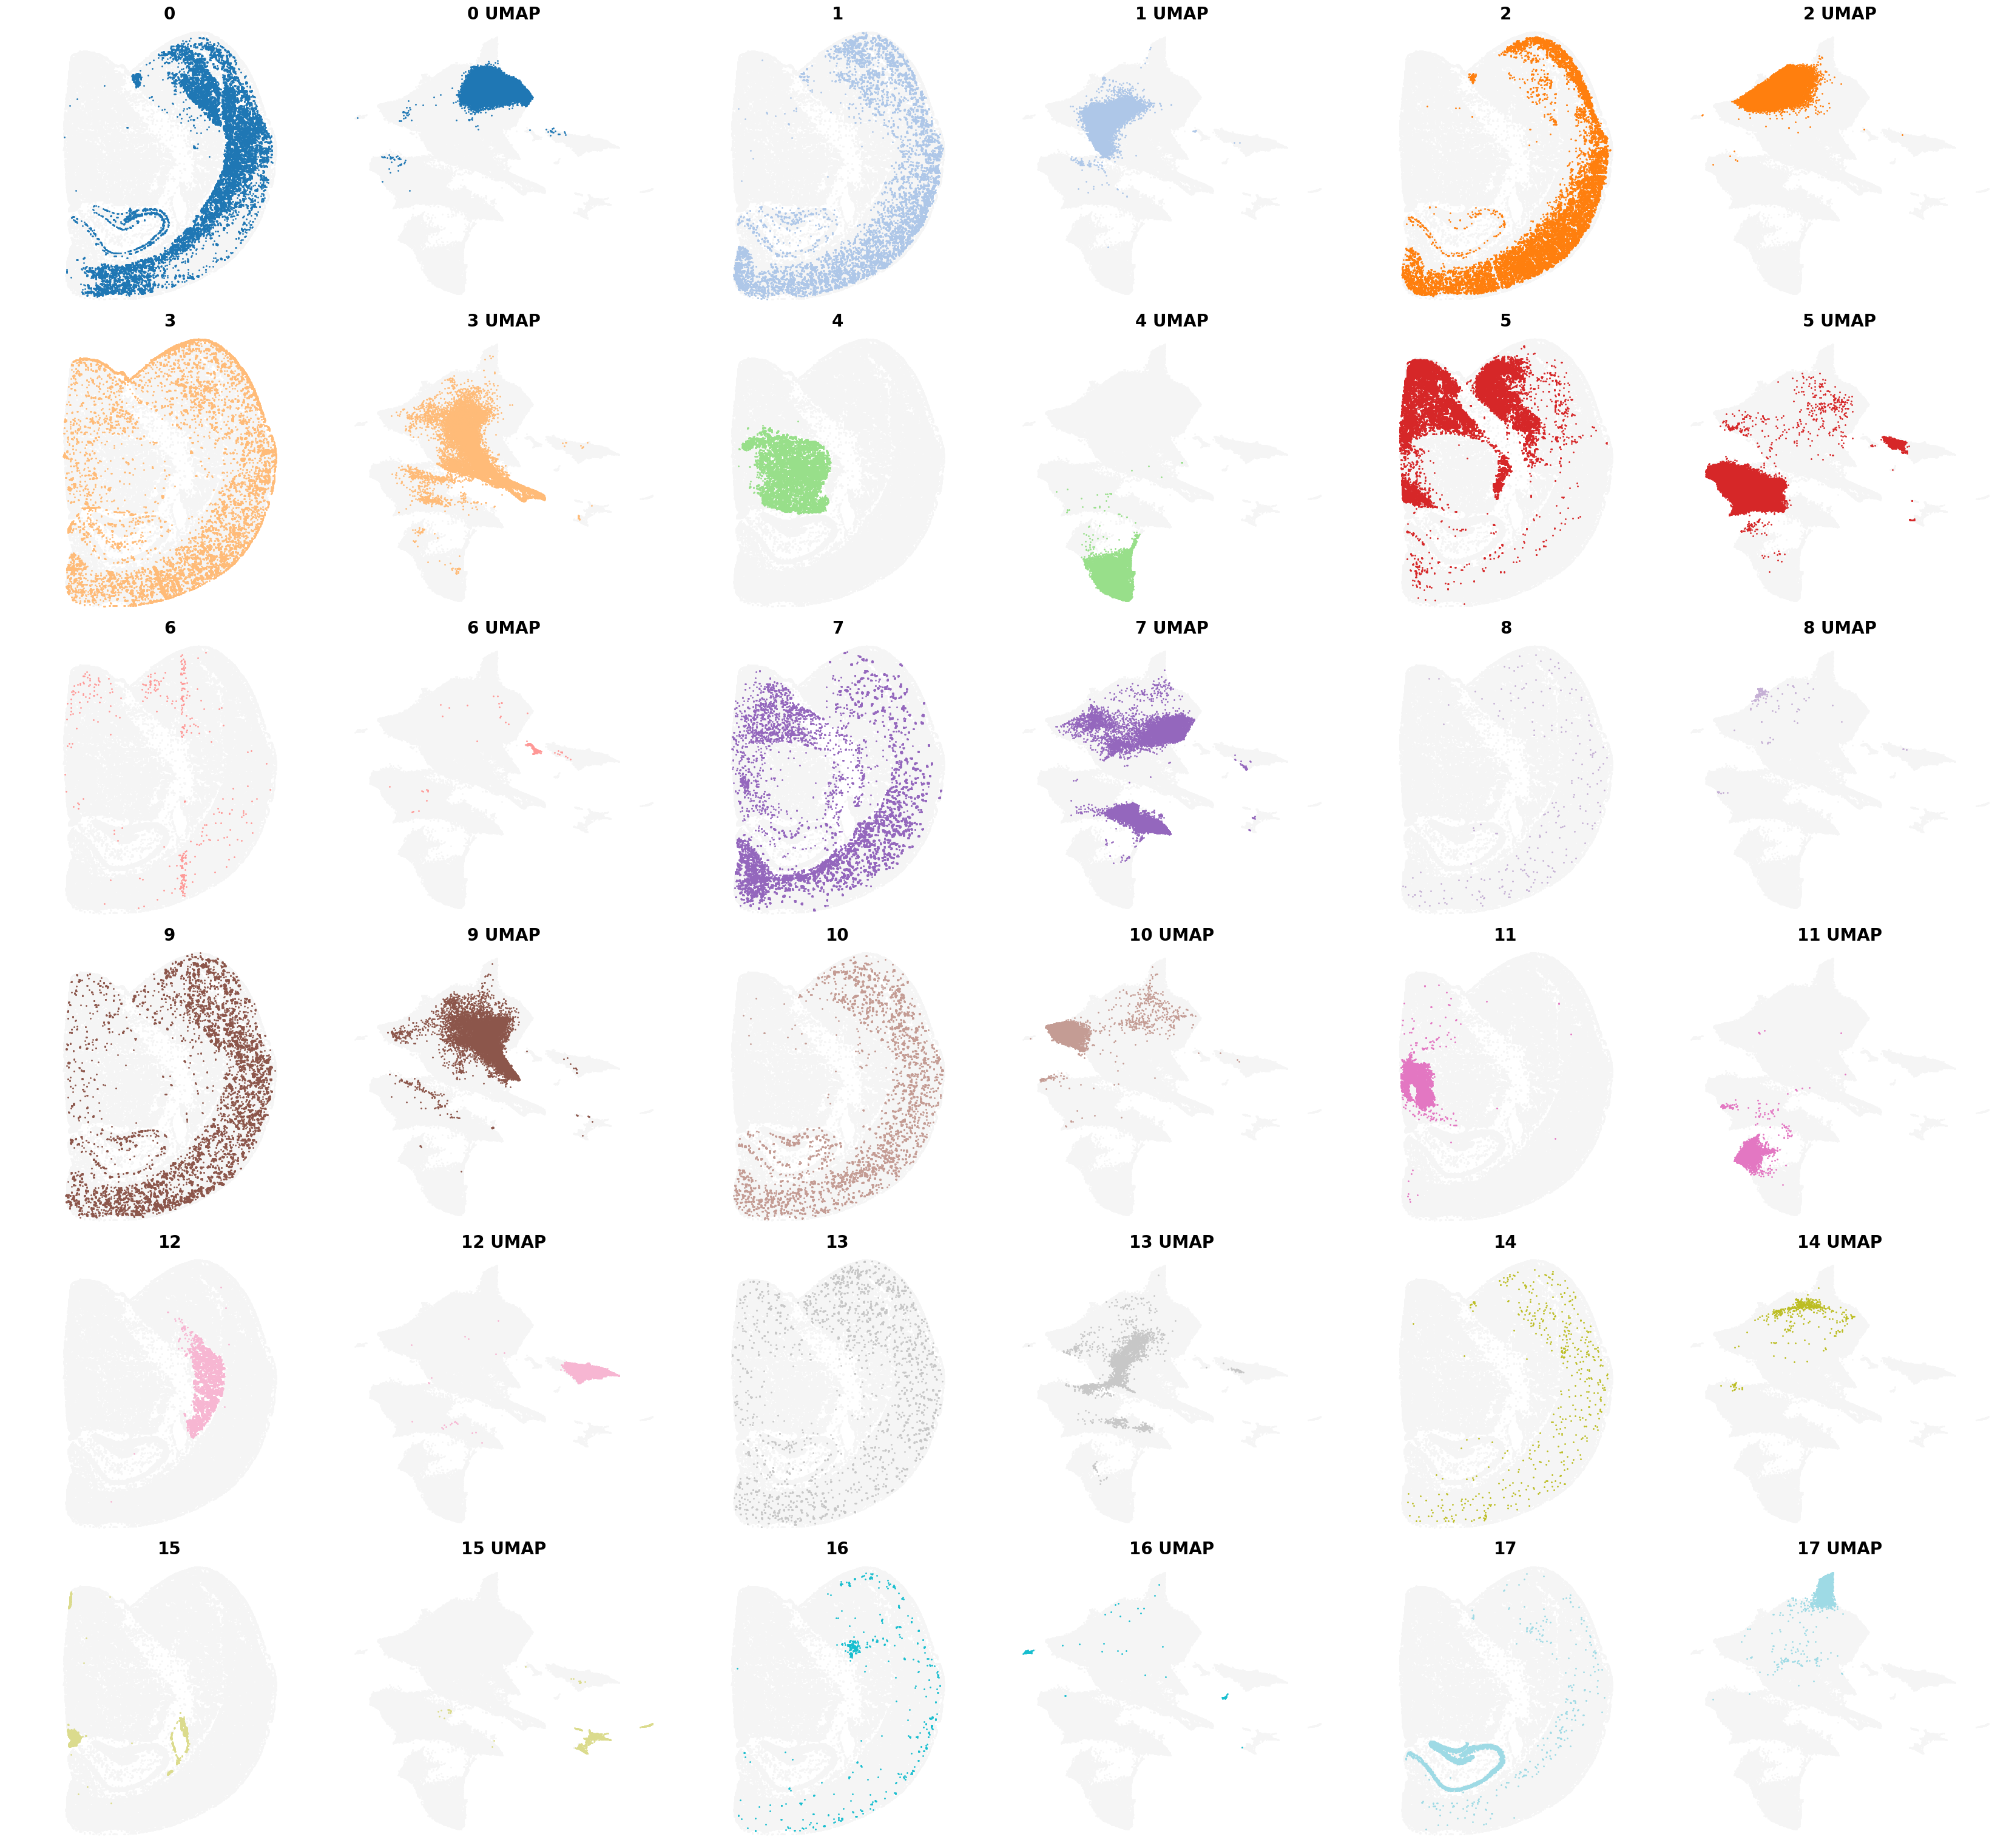

In [18]:
# 创建结果目录
result_dir = 'bpcells_banksy_results'
os.makedirs(result_dir, exist_ok=True)
coord_keys = ('array_col', 'array_row', 'spatial')

plot_results(
    results_df,
    weights_graph,
    c_map,
    match_labels=True,
    coord_keys=coord_keys,
    max_num_labels=max_num_labels,
    save_path=result_dir,
    save_fig=True
)

In [38]:
from banksy_utils.cluster_utils import pad_clusters, create_spatial_nonspatial_adata,  refine_cell_types

# Here we manually assign clusters to their identity using a dictionary
cluster2annotation_spatial = {
    "0" : "Gad1/Gad2",
    "2" : "Slc17a7",
    "4" : "Gfap/Aqp4",
    "5" : "Mbp/Plp1",
}

pad_clusters(cluster2annotation_spatial, list(range(max_num_labels)))

In [39]:
cluster2annotation_nonspatial = {
    "0" : "Gad1/Gad2",
    "2" : "Slc17a7",
    "4" : "Gfap/Aqp4",
    "5" : "Mbp/Plp1",
}

print(cluster2annotation_spatial,"\n", cluster2annotation_nonspatial)

# save annotations in two different anndata objects (adata_spatial and adata_nonspatial)

adata_spatial, adata_nonspatial = create_spatial_nonspatial_adata(results_df,
                                    pca_dims,
                                    lambda_list, 
                                    resolutions,
                                    cluster2annotation_spatial,
                                    cluster2annotation_nonspatial)

{'0': 'Gad1/Gad2', '2': 'Slc17a7', '4': 'Gfap/Aqp4', '5': 'Mbp/Plp1', '1': 'other', '3': 'other', '6': 'other', '7': 'other', '8': 'other', '9': 'other', '10': 'other', '11': 'other', '12': 'other', '13': 'other', '14': 'other', '15': 'other', '16': 'other', '17': 'other'} 
 {'0': 'Gad1/Gad2', '2': 'Slc17a7', '4': 'Gfap/Aqp4', '5': 'Mbp/Plp1'}
scaled_gaussian_pc20_nc0.20_r0.50
nonspatial_pc20_nc0.00_r0.50


In [40]:
from banksy_utils.plot_utils import plot_DE_genes, plot_DE_genes_refined, plot_connection_grid, plot_clusters

cluster2annotation_refine = {
   # "Boundary_Interface_Cells" : "other",
}

adata_spatial_filtered, adata_nonspatial_filtered = refine_cell_types(adata_spatial, 
                                                                      adata_nonspatial,
                                                                      cluster2annotation_refine
                                                                      )

In [41]:
adata_self = plot_DE_genes_refined(adata_spatial_filtered, plot_heatmap = False, save_fig = False)

         Falling back to preprocessing with `sc.pp.pca` and default params.


All refined cell types: Index(['Gad1/Gad2', 'Gfap/Aqp4', 'Mbp/Plp1', 'Slc17a7', 'other'], dtype='object')
[1. 1. 1. ... 1. 1. 1.] (200623, 200623)
[1. 1. 1. ... 1. 1. 1.] (200623, 200623)


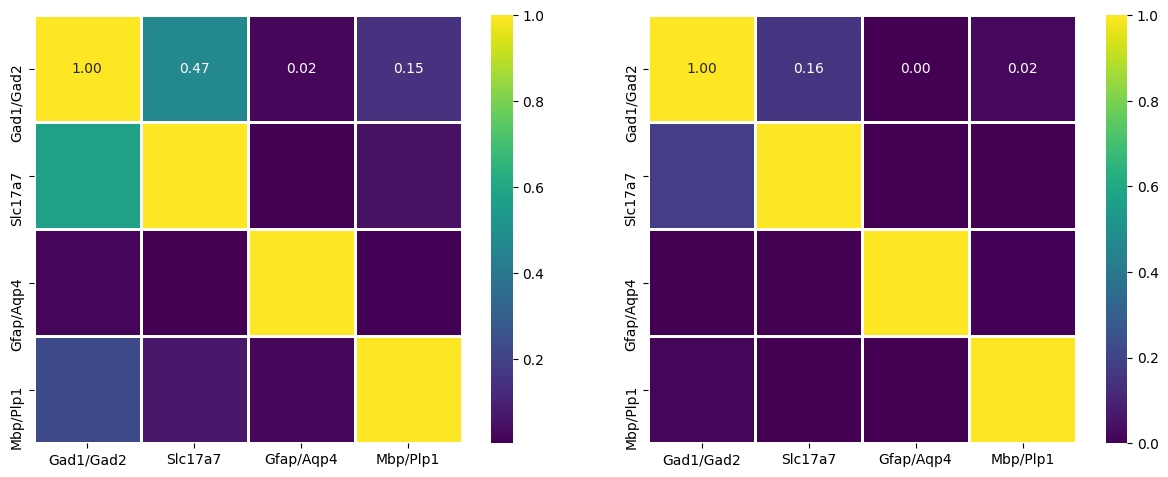

In [46]:
cell_types = ["Gad1/Gad2",
             "Slc17a7",
             "Gfap/Aqp4",
             "Mbp/Plp1"]

plot_connection_grid(
    banksy_dict["scaled_gaussian"]["weights"][0].copy(),
    adata_nonspatial,
    adata_spatial,
    cell_types= cell_types,
    save_fig=False
)

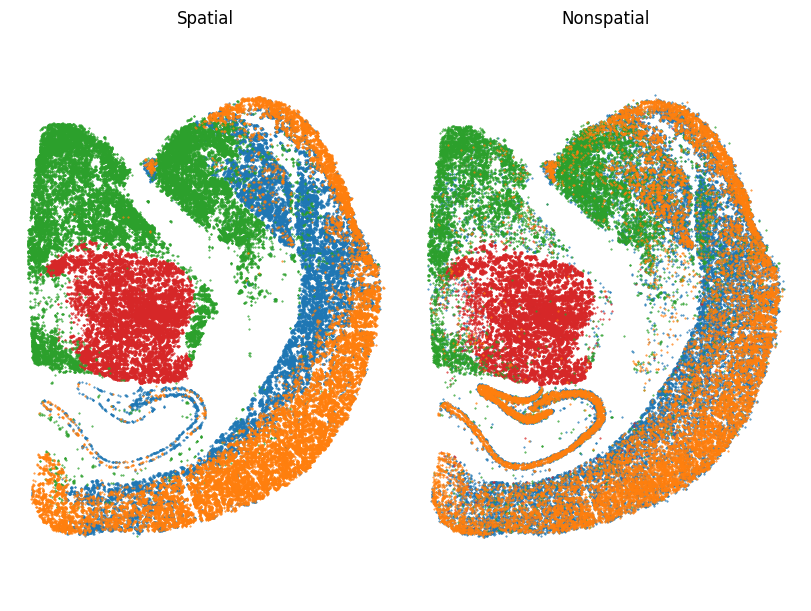

In [43]:
adata_spatial.obsm['coord_xy'] = adata_spatial.obsm['spatial']
adata_nonspatial.obsm['coord_xy'] = adata_nonspatial.obsm['spatial']
# choose colours for each cluster
colors_dict = {
    "Gad1/Gad2":"tab:blue",
    "Slc17a7":"tab:orange",
    "Gfap/Aqp4":"tab:red",
    "Mbp/Plp1":"tab:green",
}

plot_clusters(
    adata_spatial,
    adata_nonspatial,
    colors_dict,
)